
# MainGames Data Scientist Analysis

**Objective:** Identify factors that influence `PaidStarPerWatchedHour` and generate business recommendations.


In [273]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("D:/Dinda/Maingames/data/Maingames_DS_dataset.csv")
print(df.shape)
df.head()


(631, 127)


,Unnamed: 0,Country,Gender,Game,Total Follower,Broadcast Hours,PaidStarPerWatchedHour,Character_Facet_Cont_Rigidity,Character_Facet_Cont_AchievementStriving,Personal_Values_Facet_Cont_Hedonism,...,Personal_Values_Facet_Cont_UniversalismNature,Role_Charismatic,Personal_Values_Facet_Cont_Tradition,Self_Esteem_Cont_SELevelAppearance,Character_Facet_Cont_Assertiveness,Character_Facet_Cont_Cautiousness,Role_Curator,Personal_Values_Cont_Conservation,Self_Esteem_Cont_SELevelIntelligence,Temperament_Centric
0,0,ID,Male,MLBB,96751,104,0.004113,0.663442,0.718679,0.288008,...,0.523116,0.408444,0.318747,0.684412,0.494384,0.751974,0.524306,0.299052,0.803920,0.625
1,1,ID,Male,8 Ball Pool,4781,174,0.002855,0.543255,0.427887,0.430609,...,0.444493,0.407624,0.382594,0.635493,0.468738,0.571198,0.100202,0.304527,0.751291,0.125
2,2,ID,Female,Free Fire - Battlegrounds,68246,83,0.003007,0.527279,0.399873,0.753009,...,0.581657,0.443453,0.325263,0.398686,0.515929,0.309322,0.070988,0.305975,0.759900,0.000
3,3,ID,Male,MLBB,142037,127,0.005171,0.677222,0.603534,0.407923,...,0.385822,0.408994,0.440821,0.703669,0.516412,0.535322,0.214652,0.298592,0.734010,0.000
4,4,ID,Male,Free Fire - Battlegrounds,15416,86,0.001213,0.238194,0.543285,0.392993,...,0.582025,0.135650,0.405968,0.439668,0.586193,0.567604,0.324364,0.298716,0.814530,0.125


## 1. Data Overview

In [274]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Columns: 127 entries, Unnamed: 0 to Temperament_Centric
dtypes: float64(120), int64(2), str(5)
memory usage: 626.2 KB


In [275]:

df.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,631.0,NaN,NaN,NaN,465.057052,313.809365,0.0,160.5,432.0,787.5,946.0
Country,631,3,VN,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,3,Male,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Game,629,65,MLBB,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Follower,630,628,40837,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Broadcast Hours,631.0,NaN,NaN,NaN,127.870048,53.127032,0.0,92.0,113.0,151.5,571.0
PaidStarPerWatchedHour,629.0,NaN,NaN,NaN,0.012047,0.103878,0.0,0.00091,0.002594,0.007003,2.561621
Character_Facet_Cont_Rigidity,631.0,NaN,NaN,NaN,0.602272,0.098965,0.238194,0.548895,0.592589,0.668015,0.869732
Character_Facet_Cont_AchievementStriving,631.0,NaN,NaN,NaN,0.511264,0.132756,0.09229,0.378814,0.523694,0.615077,0.803543
Personal_Values_Facet_Cont_Hedonism,631.0,NaN,NaN,NaN,0.504968,0.110216,0.203574,0.438643,0.53855,0.571307,0.853163


In [276]:
df.shape

(631, 127)

In [277]:
df["PaidStarPerWatchedHour"].describe()

count    629.000000
mean       0.012047
std        0.103878
min        0.000000
25%        0.000910
50%        0.002594
75%        0.007003
max        2.561621
Name: PaidStarPerWatchedHour, dtype: float64

In [278]:
df["PaidStarPerWatchedHour"].skew()

np.float64(23.673686276191194)

## 2. Missing Values

In [279]:

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)


Game                        2
PaidStarPerWatchedHour      2
PaidStarPerWatchedHour.1    2
Total Follower              1
Gender                      1
dtype: int64

## 3. Target Variable Analysis

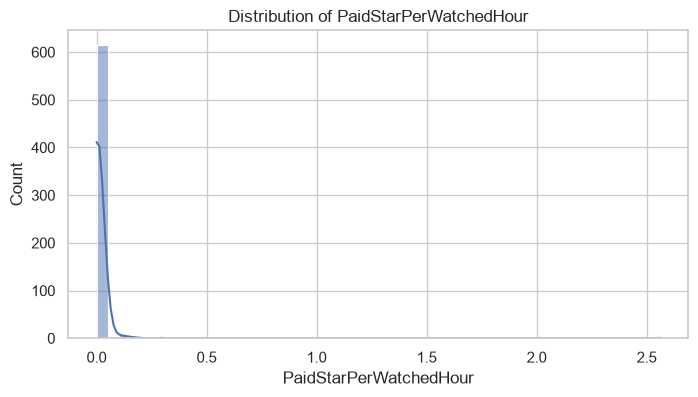

In [280]:

plt.figure(figsize=(8,4))
sns.histplot(df['PaidStarPerWatchedHour'], kde=True)
plt.title('Distribution of PaidStarPerWatchedHour')
plt.show()


## 4. Country Analysis

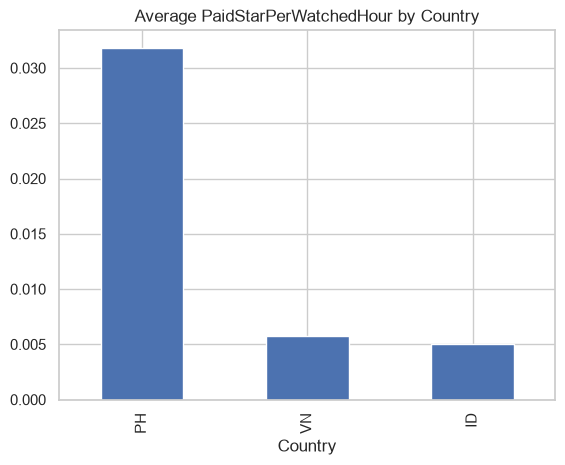

Country
PH    0.031842
VN    0.005794
ID    0.005007
Name: PaidStarPerWatchedHour, dtype: float64

In [281]:

country_avg = df.groupby('Country')['PaidStarPerWatchedHour'].mean().sort_values(ascending=False)

country_avg.plot(kind='bar')
plt.title('Average PaidStarPerWatchedHour by Country')
plt.show()

country_avg


## 5. Gender Analysis

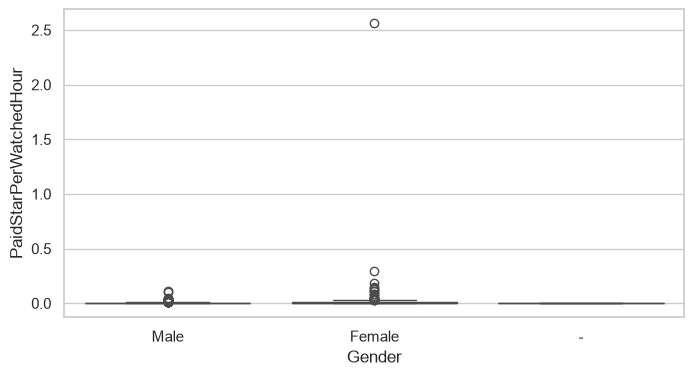

In [282]:

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Gender', y='PaidStarPerWatchedHour')
plt.show()


## 6. Game Analysis

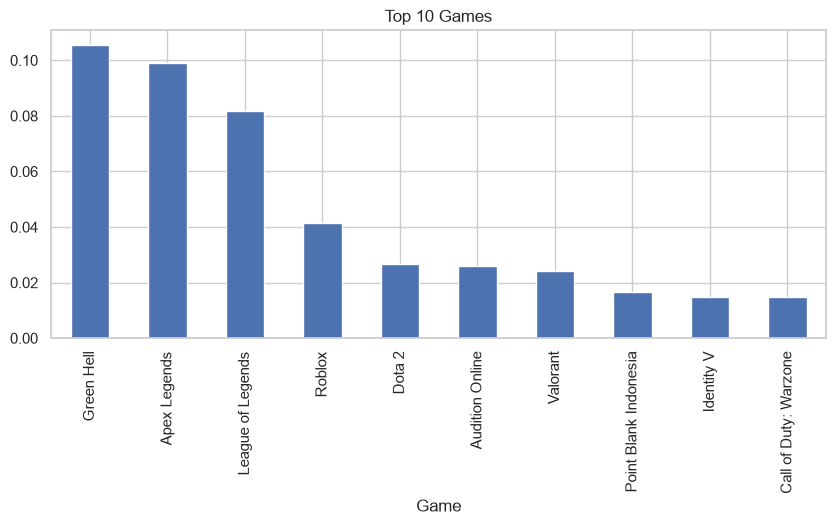

Game
Green Hell               0.105561
Apex Legends             0.098972
League of Legends        0.081605
Roblox                   0.041345
Dota 2                   0.026854
Audition Online          0.025943
Valorant                 0.024313
Point Blank Indonesia    0.016526
Identity V               0.014980
Call of Duty: Warzone    0.014799
Name: PaidStarPerWatchedHour, dtype: float64

In [283]:

game_avg = (
    df.groupby('Game')['PaidStarPerWatchedHour']
    .mean()
    .sort_values(ascending=False)
)

game_avg.head(10).plot(kind='bar', figsize=(10,4))
plt.title('Top 10 Games')
plt.show()

game_avg.head(10)


## 7. Followers vs Monetization

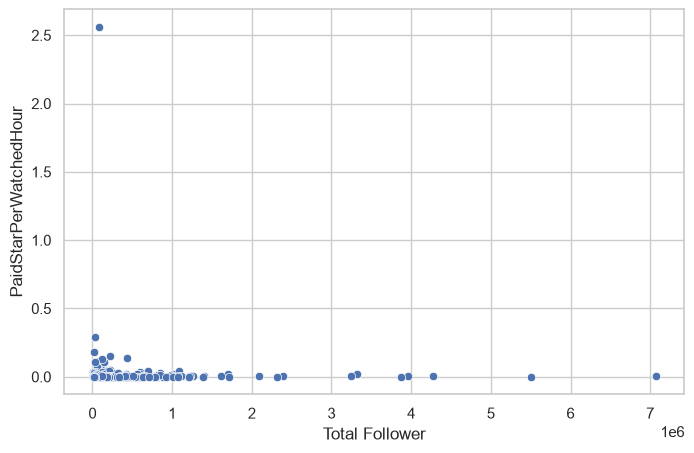

In [284]:

df['Total Follower'] = pd.to_numeric(df['Total Follower'], errors='coerce')

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Total Follower',
    y='PaidStarPerWatchedHour'
)
plt.show()


## 8. Correlation Analysis

In [285]:

corr = df.corr(numeric_only=True)

target_corr = corr['PaidStarPerWatchedHour'].sort_values(ascending=False)

target_corr.head(20)



PaidStarPerWatchedHour                            1.000000
PaidStarPerWatchedHour.1                          1.000000
Personal_Values_Facet_Cont_Hedonism               0.140685
Character_Facet_Cont_Morality                     0.110888
Personal_Values_Facet_Cont_PowerDominance         0.103700
Temperament_Diligent                              0.100949
Self_Esteem_Cont_SEDiscrepancy                    0.096642
Personal_Values_Facet_Cont_Humility               0.085590
Self_Esteem_Cont_SEAspirationAppearance           0.083880
Personal_Values_Cont_SelfTranscendence            0.083687
Personal_Values_Facet_Cont_Reputation             0.081787
Role_Craftsman                                    0.068343
Self_Esteem_Cont_SEAspirationSociability          0.067341
Personal_Values_Facet_Cont_SelfDirectionAction    0.061797
Self_Esteem_Cont_SEDiscrepancyConfidence          0.060979
Character_Facet_Cont_SelfConsciousness            0.059360
Personal_Values_Facet_Cont_UniversalismConcern    0.0563

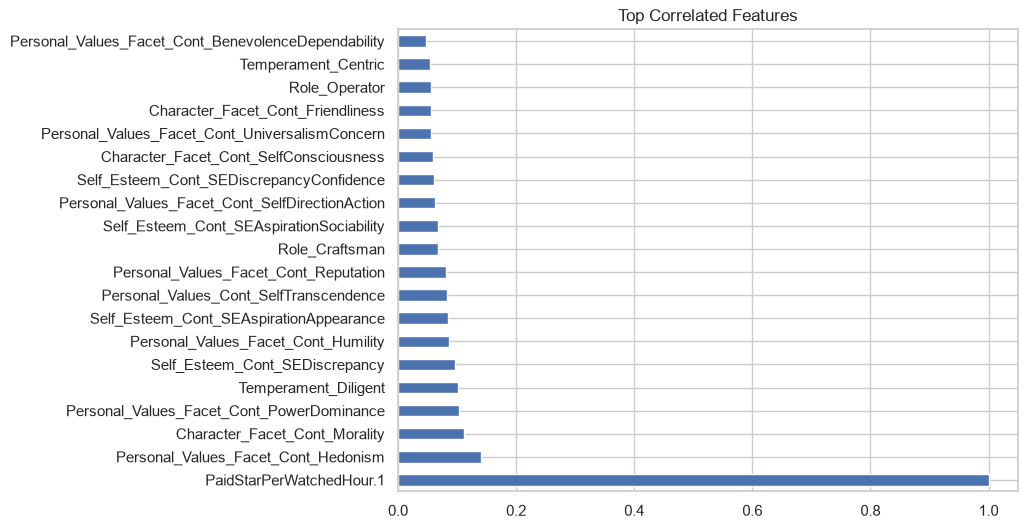

In [286]:

target_corr[1:21].plot(kind='barh', figsize=(8,6))
plt.title('Top Correlated Features')
plt.show()


In [287]:
df = df.dropna(subset=["PaidStarPerWatchedHour"])

## 9. Machine Learning - Random Forest

In [288]:

categorical_cols = [
    c for c in ['Country','Gender','Game']
    if c in df.columns
]

df_ml = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

X = df_ml.drop(columns=['PaidStarPerWatchedHour'])

X = X.select_dtypes(include=np.number)

y = df_ml['PaidStarPerWatchedHour']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print('R2:', r2_score(y_test, pred))
print('MAE:', mean_absolute_error(y_test, pred))


R2: -26.514841897687663
MAE: 0.010368965879550236


In [289]:
import numpy as np 
df_ml = df.copy()

# Hapus kolom Index yang tidak berguna
df_ml = df_ml.drop(columns=['unnamed: 0'], errors='ignore')

# Hapus baris yang targetnya kosong
df_ml = df_ml.dropna(subset=['PaidStarPerWatchedHour'])

#Transformasilog pada Target
df_ml['PaidStar_log'] = np.log1p(
    df_ml['PaidStarPerWatchedHour']
)

print(df_ml.shape)

(629, 128)


In [290]:
categorycal_col = [
    c for c in X.columns
    if "PaidStar" in c
]

df_model = pd.get_dummies(
    df_ml,
    columns=categorical_cols,
    drop_first=True
)

# X = semua fitur kecuali target asli dan target log
X = df_model.drop(
    columns=[
        'PaidStarPerWatchedHour',
        'PaidStarPerWatchedHour.1',
        'PaidStar_log',
        'Unnamed: 0'
    ],
    errors='ignore'
)

# Ambil hanya kolom numerik
X = X.select_dtypes(include=np.number)

# Isi Missing Value Jika ada
X = X.fillna(X.median())

# Target Baru
y = df_model['PaidStar_log']

print("PaidStar_log" in X.columns,
    "Unnamed: 0" in X.columns)

False False


In [291]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: -12.901918669374625
MAE: 0.013823247105855549


## 10. Feature Importance

In [292]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)


,Feature,Importance
101,Role_Strategist,0.195009
4,Personal_Values_Facet_Cont_Hedonism,0.168102
44,Role_Guru,0.143761
0,Total Follower,0.083625
3,Character_Facet_Cont_AchievementStriving,0.061600
1,Broadcast Hours,0.035954
115,Character_Facet_Cont_Cautiousness,0.026012
16,Character_Cont_Extraversion,0.023147
25,Personal_Values_Facet_Cont_PowerDominance,0.022189
29,Personal_Values_Cont_SelfEnhancement,0.017740


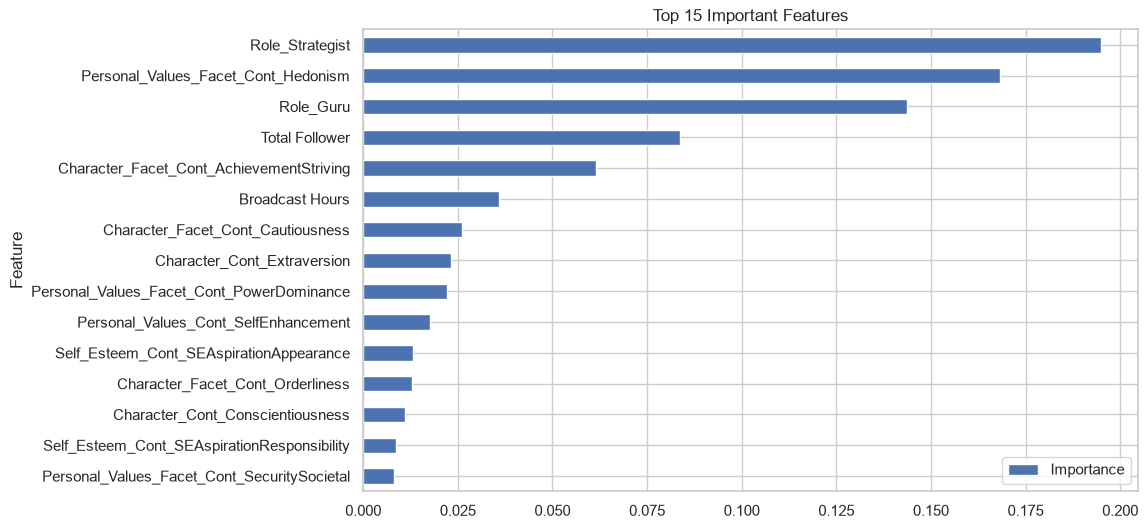

In [293]:

importance.head(15).sort_values('Importance').plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 15 Important Features')
plt.show()
